## Non-standard primordial power spectrum (wavepacket oscillation)

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
import math
from camb import model, initialpower
print('Using CAMB %s'%(camb.__version__))

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Using CAMB 1.5.9
Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data


<Figure size 640x480 with 0 Axes>

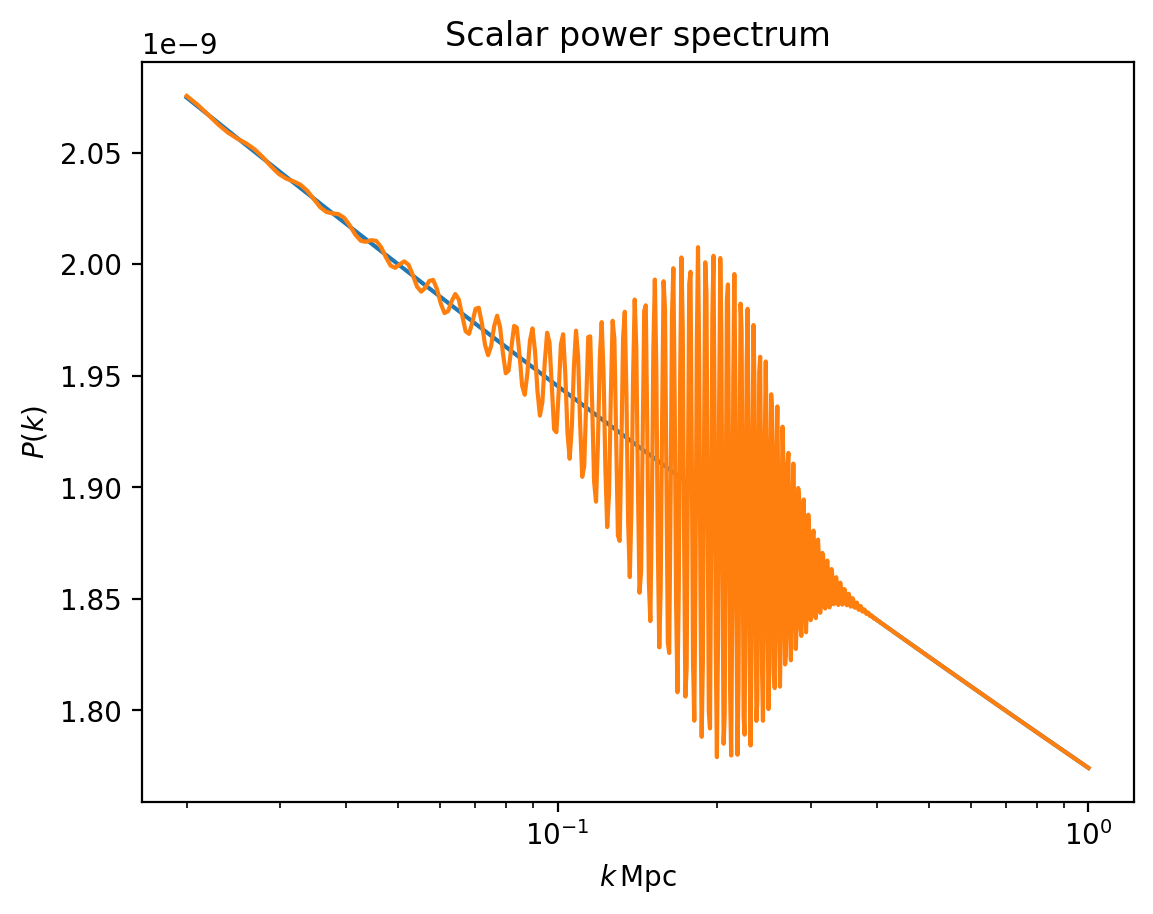

<Figure size 640x480 with 0 Axes>

In [2]:
from CMBFeatureNet import PK
freq = 1000
ks = np.linspace(0.02,1,1000)
pk1 = 2e-9*(ks/0.05)**(0.96-1)
pk2 = PK(ks,2e-9, 0.96,0.0599,freq, 0.08, 0.2,0)
plt.semilogx(ks,pk1)
plt.semilogx(ks,pk2)
plt.ylabel('$P(k)$')
plt.xlabel(r'$k\, {\rm Mpc}$');
plt.title('Scalar power spectrum')
plt.figure()

In [3]:
#Planck TT data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT1 = data_Planck[:, 2]
sdl_Planck_TT2 = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

#Planck TE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE1 = data_Planck[:, 2]
sdl_Planck_TE2 = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

#Planck EE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE1 = data_Planck[:, 2]
sdl_Planck_EE2 = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

In [4]:
Tcmb = 2.7255
CF = (Tcmb*10**6)**2

#Converting the c_ls^TT to Dls
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Conerting Dls to the c_ls^TT
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(CF*l[i]*l[i]+1)*DlTT[i] for i in range(len(l))]
    return ClTT

In [5]:
#Read Covariance matrices
base_pathCV = "./simulated_data/simulated_cov_matrices"
cov_matx_dltt_mcmc = np.loadtxt(base_pathCV +'/dlstt_cov_matx(mcmc).csv', delimiter=",")
cov_matx_dlte_mcmc = np.loadtxt(base_pathCV +'/dlste_cov_matx(mcmc).csv', delimiter=",")
cov_matx_dlee_mcmc = np.loadtxt(base_pathCV +'/dlsee_cov_matx(mcmc).csv', delimiter=",")

In [6]:
from CMBFeatureNet import generate_camb_power_spectra
Power_spectra = generate_camb_power_spectra(67.4, 0.02237, 0.1200, 0.06, 0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507, custom_PK=True, 
                    amp=0.0599, freq=freq, wid=0.08, centre=0.2, phase=0)

<class 'functions.simulate_data.CMBPowerSpectra'>


In [7]:
Power_spectra_big = generate_camb_power_spectra(67.4, 0.02237, 0.1200, 0.06, 0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507, custom_PK=True, 
                    amp=1, freq=freq, wid=0.08, centre=0.2, phase=0)

<class 'functions.simulate_data.CMBPowerSpectra'>


In [8]:
Power_spectra_normal = generate_camb_power_spectra(67.4, 0.02237, 0.1200, 0.06, 0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507, custom_PK=False)

<class 'functions.simulate_data.CMBPowerSpectra'>


/tmp/ipykernel_4017631/1025075660.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


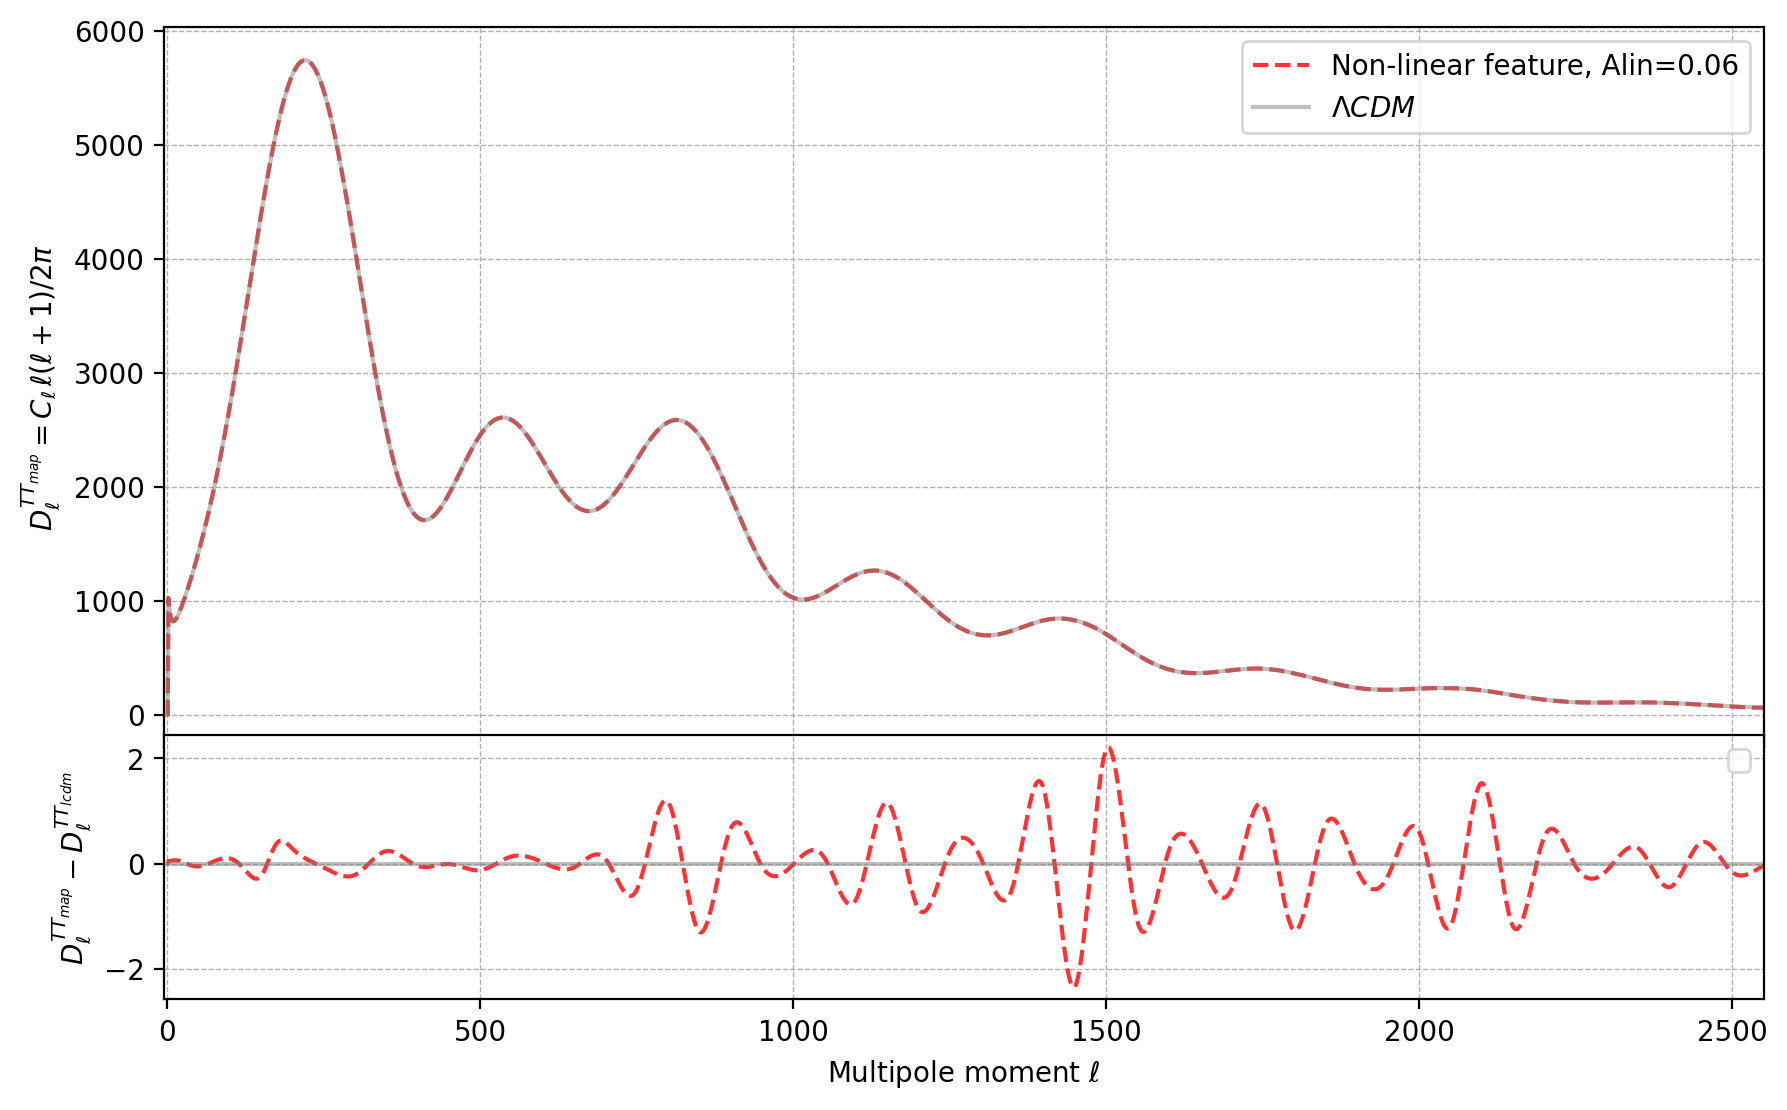

In [9]:
fig = plt.figure(figsize=(10, 6))
frame1 = fig.add_axes((.1, .4, .8, .6))

plt.plot(Power_spectra[0], Power_spectra[1], label='Non-linear feature, Alin=0.06', alpha=0.8, color='red', linestyle='--')
plt.plot(Power_spectra_normal[0], Power_spectra_normal[1], label='$\Lambda CDM$', alpha=0.5, color='gray')
#plt.plot(Power_spectra_big[0], Power_spectra_big[1], label='Custom Pk, Alin=1', alpha=0.5, color='blue')
plt.ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
plt.xlim(-5, len(Power_spectra[0]))
plt.tick_params(axis='x', labelsize=0.1)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()

frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
plt.plot(Power_spectra[0], Power_spectra[1] - Power_spectra_normal[1], alpha=0.8, color='red', linestyle='--')
plt.axhline(y=0, color='gray', alpha=0.5)  # Horizontal line at y=0
#plt.plot(Power_spectra_big[0], Power_spectra_big[1] - Power_spectra_normal[1],
#         label='Difference Alin=1', alpha=0.5, color='blue')
plt.xlabel(r'Multipole moment $\ell$')
plt.ylabel(r'$D_\ell^{TT_{map}} - D_\ell^{TT_{lcdm}}$')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()

plt.show()

In [ ]:
from CMBFeatureNet import add_noise_spectrum
from CMBFeatureNet import PK
from CMBFeatureNet import generate_camb_power_spectra
from CMBFeatureNet import save_power_spectrum
seed0 = 314100

#Conerting Dls to the c_ls^TT (in μK^2)
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(l[i]*(l[i]+1))*DlTT[i] for i in range(len(l))]
    return ClTT

base_pathCV = "./simulated_data/simulated_cov_matrices/"
cov_matx_dltt_mcmc = np.loadtxt(base_pathCV +'/dlstt_cov_matx(mcmc).csv', delimiter=",")

#dlstt_noisy_feature = add_noise_spectrum(Power_spectra.tt, cov_matx_dltt_mcmc, seed0)
#dlstt_noisy_lcdm = add_noise_spectrum(Power_spectra_normal.tt, cov_matx_dltt_mcmc, seed0)

np.random.seed(seed0)
dlstt_noisy_feature = np.random.multivariate_normal(Power_spectra.tt[:len(cov_matx_dltt_mcmc)], cov_matx_dltt_mcmc, 1)
np.random.seed(seed0)
dlstt_noisy_lcdm = np.random.multivariate_normal(Power_spectra_normal.tt[:len(cov_matx_dltt_mcmc)], cov_matx_dltt_mcmc, 1)

cl_tt_feature = Cls(round_ls_Pl_TT, dlstt_noisy_feature[0])
cl_tt_lcdm = Cls(round_ls_Pl_TT, dlstt_noisy_lcdm[0])

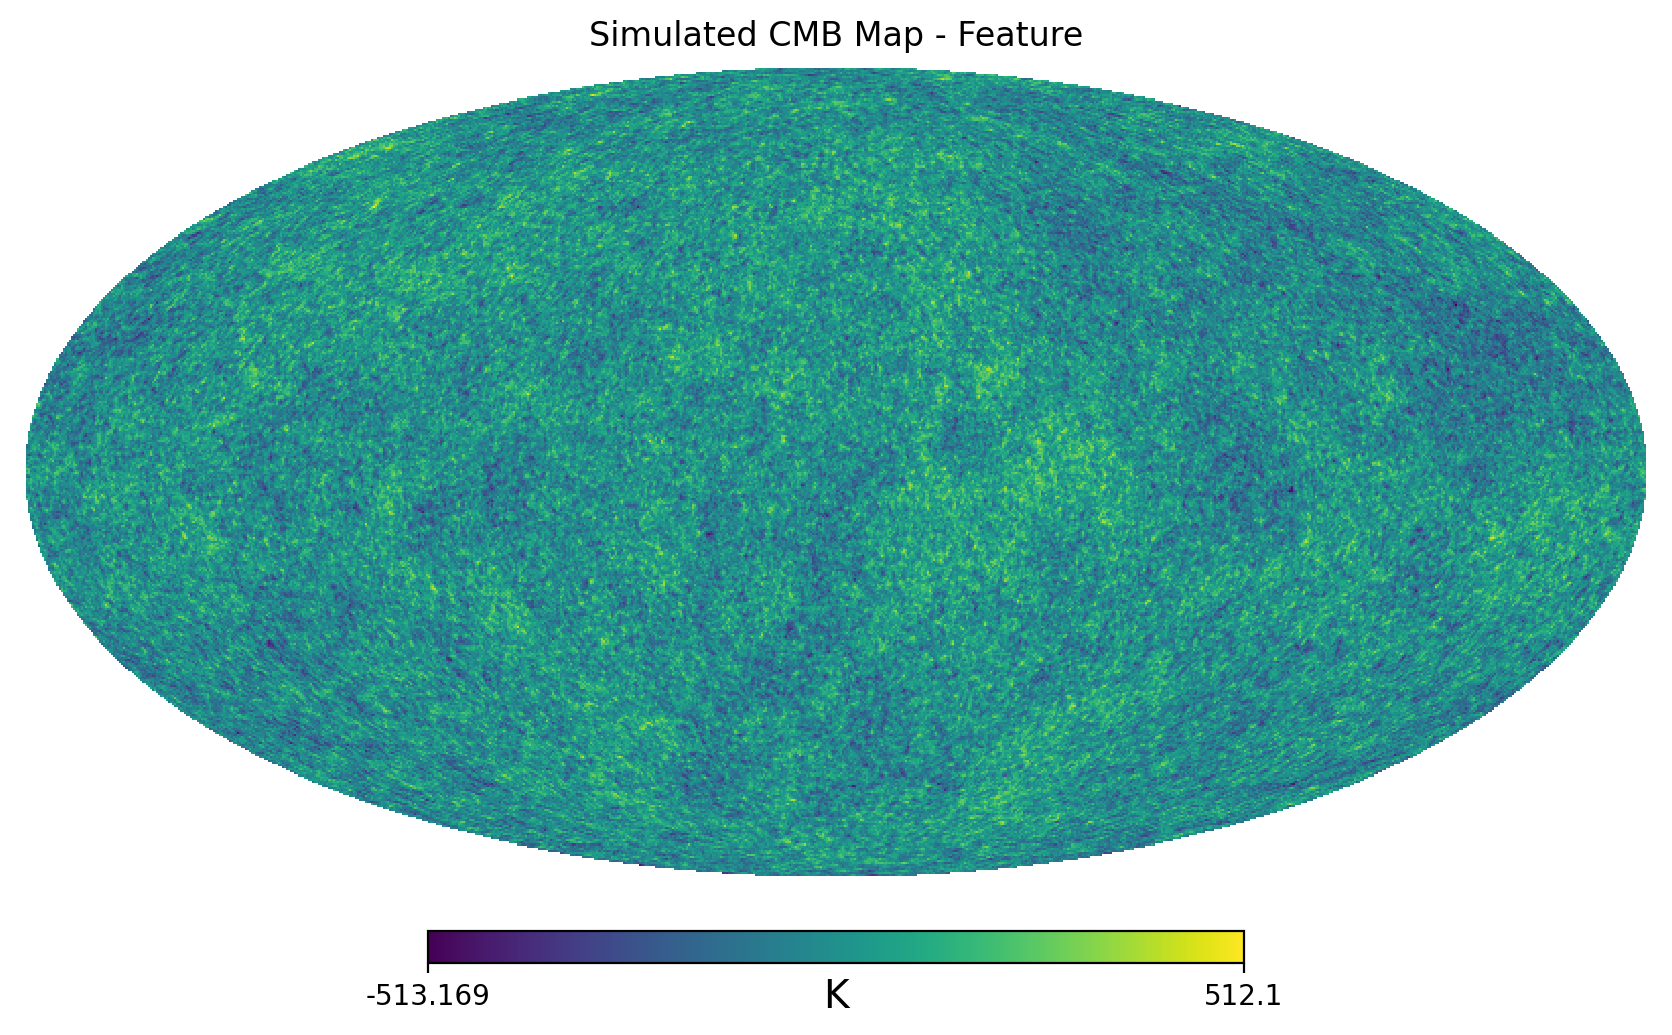

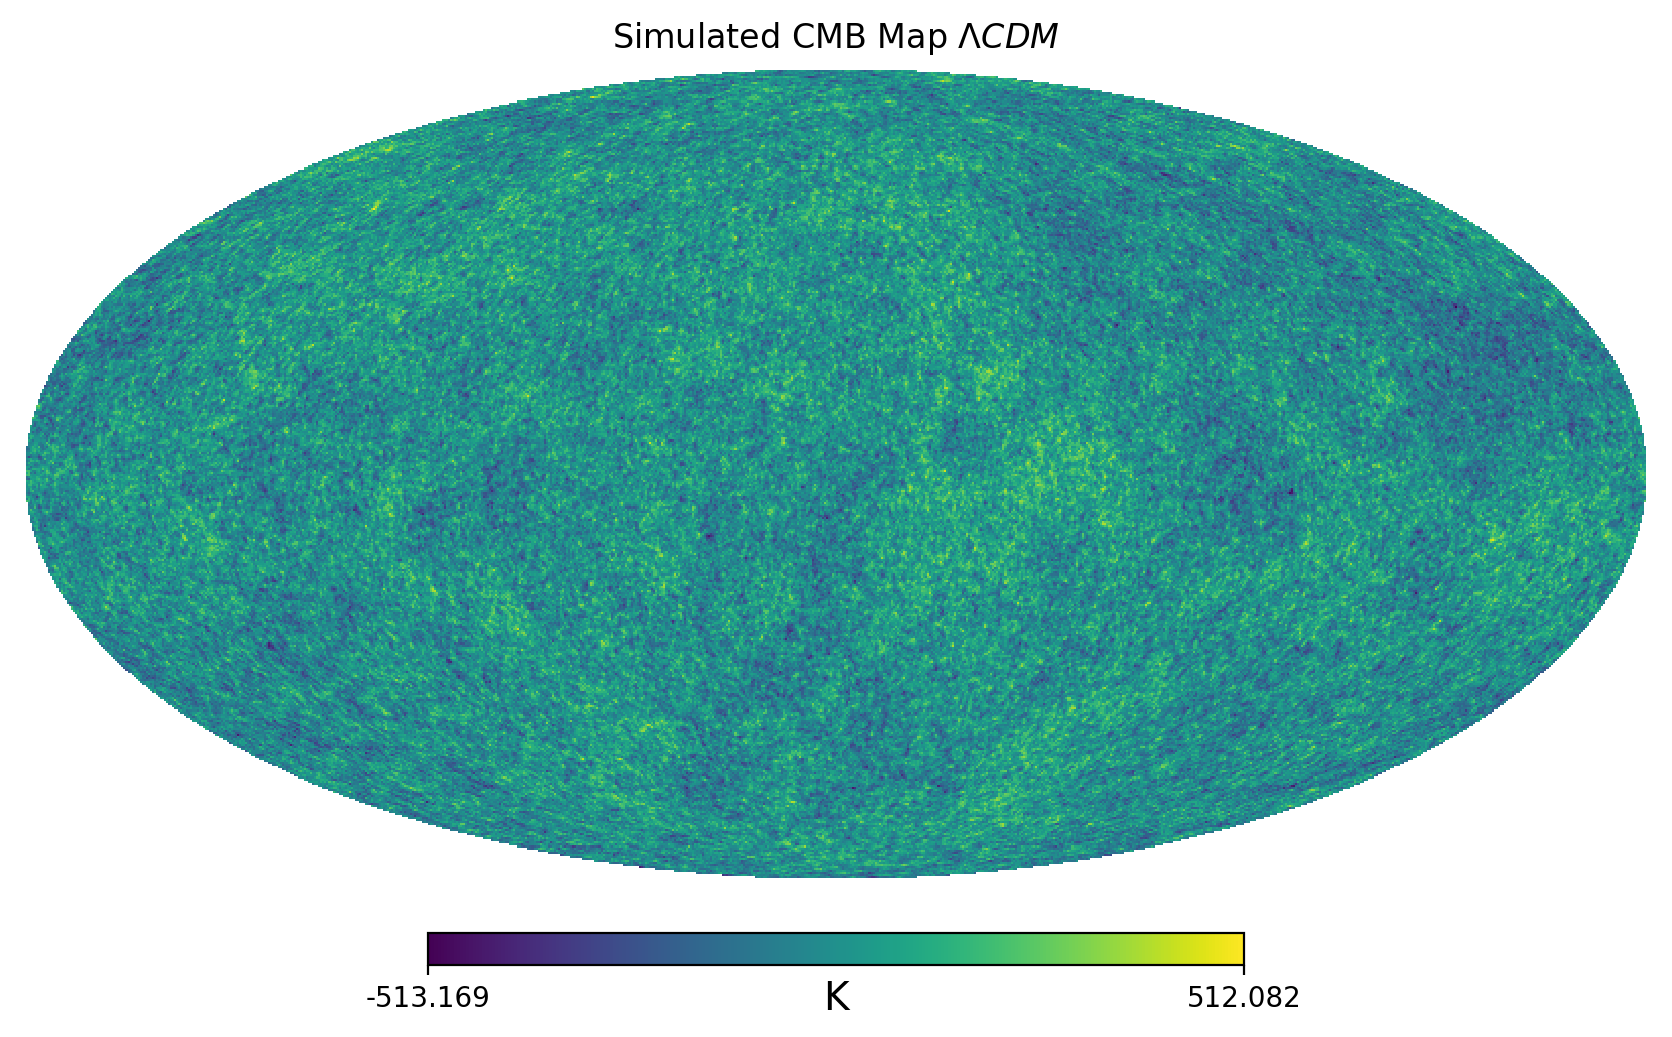

In [20]:
#from CMBFeatureNet import generate_cmb_temperature_map
#Generate and visualize the CMB map
#Generate CMB map using Healpy
import healpy as hp
np.random.seed(seed0)
cmb_map_feature = hp.synfast(cl_tt_feature, nside=1024, new=True, sigma=None)
np.random.seed(seed0)
cmb_map_lcdm = hp.synfast(cl_tt_lcdm, nside=1024, new=True, sigma=None)

#Visualize
hp.mollview(cmb_map_feature, title="Simulated CMB Map - Feature", unit="K")
hp.mollview(cmb_map_lcdm, title="Simulated CMB Map $\Lambda CDM$", unit="K")

/tmp/ipykernel_4017631/2284071943.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame2.legend()


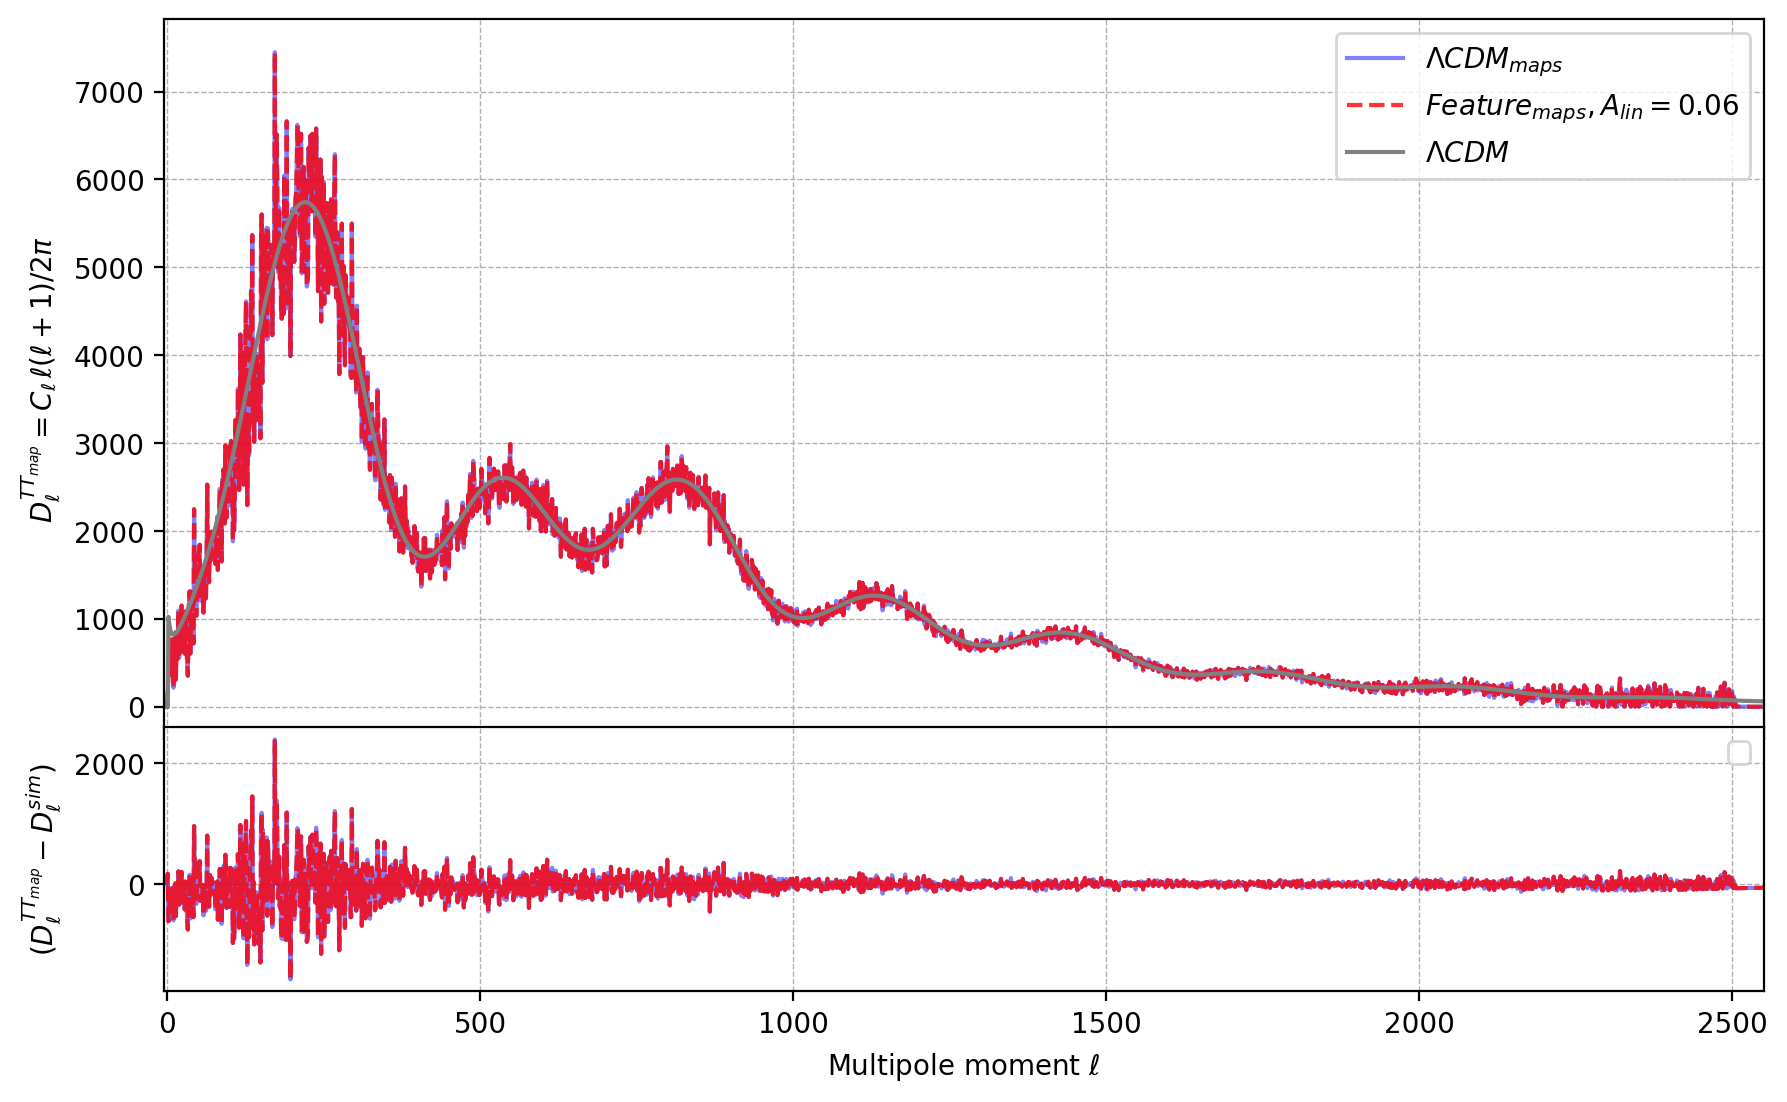

In [21]:
#Compute the power spectra
cl_tt_map_feature = hp.anafast(cmb_map_feature, pol=True)
cl_tt_map_lcdm = hp.anafast(cmb_map_lcdm, pol=True)

ell = np.arange(len(Power_spectra[0]))
#lmax = len(cl_tt_map)
lmax = len(cl_tt_map_feature)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_lcdm)[:lmax], 
            label='$\Lambda CDM_{maps}$', alpha=0.5, color='blue')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_feature)[:lmax], 
            label='$Feature_{maps}, A_{lin}=0.06$', alpha=0.8, color='red', linestyle='--')
frame1.plot(ell, Power_spectra_normal[1], 
            label='$\Lambda CDM$', color='gray')
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, len(Power_spectra[0]))
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()
 
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - Power_spectra_normal[1][:lmax])
diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - Power_spectra_normal[1][:lmax])
frame2.plot(ell[:lmax], diff2, color='blue', alpha=0.5)
frame2.plot(ell[:lmax], diff1, alpha=0.8, color='red', linestyle='--')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{TT_{map}} - D_\ell^{sim})$')
frame2.tick_params(axis='x', labelsize=10)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)
frame2.legend()

plt.show()